In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
feature_groups = {
    "trend": [
        "ema_20","ema_50","ema_200","adx","rsi_14",
        "ppo","ppo_signal","ppo_hist"
    ],
    "momentum": [
        "log_return_1h","log_return_4h","log_return_1d",
        "mfi_14","swing_high","swing_low",
        "last_swing_high","last_swing_low"
    ],
    "volatility": [
        "atr_200","atr_pct","atr_vol_regime","atr_vol_regime_z",
        "range_atr","body_atr","roll_std_4h","roll_std_8h",
        "bb_width","bb_percent","bb_z","bb_percB",
        "fd_volatility","fd_vol_ratio","fd_vol_slope",
        "fd_slope_atr_norm","fd_vol_adjusted",
        "fd_volatility_robust_z","fd_vol_ratio_robust_z",
        "fd_vol_slope_robust_z","fd_slope_atr_norm_robust_z",
        "fd_vol_adjusted_robust_z","fd_regime","fd_regime_switch"
    ],
    "liquidity": [
        "volume","z_volume","funding_rate",
        "funding_bias","vwap","vwap_distance"
    ],
    "market_structure": [
        "bos_bullish","bos_bearish",
        "choch_bullish","choch_bearish",
        "mss_bullish","mss_bearish",
        "bullish_fvg","bearish_fvg","fvg_gap",
        "rolling_high","rolling_low","equilibrium",
        "breakout_bullish","breakout_bearish",
        "dist_daily_high","dist_daily_low",
        "dist_weekly_high","dist_weekly_low",
        "pattern_bullish_engulf","pattern_bearish_engulf",
        "pattern_harami","pattern_hammer",
        "pattern_inverted_hammer","pattern_count",
        "pattern_active","pda_Discount","pda_Premium"
    ],
    "behavioral": ["fear_greed"],
    "macro": [
        "macro_event_flag","macro_event_intensity",
        "macro_event_intensity_smooth","macro_event_sentiment"
    ],
    "onchain": ["onchain_activity_index"],
    "time": [
        "hour_sin","hour_cos","dayofweek_sin","dayofweek_cos",
        "session_Asia","session_Frankfurt","session_London",
        "session_NewYork","session_OffHours",
        "vwap_session","session_vol_mean","session_return_mean",
        "session_volatility"
    ]
}


In [5]:
df_raw = pd.read_csv("artifacts/feature_importance_comparison_ku6.0_kd2.0_hold336.csv")
df_raw

,Feature,CatBoost,LightGBM,XGBoost,RandomForest,avg_importance
0,adx,0.000000,0.341015,0.339848,0.296506,0.244342
1,atr_pct,0.448190,1.000000,0.824057,0.819273,0.772880
2,atr_vol_regime,0.272199,0.480163,0.673701,0.545812,0.492969
3,atr_vol_regime_z,0.370305,0.367853,0.871055,0.395781,0.501248
4,bb_percB,0.000000,0.003646,0.000000,0.077058,0.020176
...,...,...,...,...,...,...
99,volume,0.000000,0.039819,0.039356,0.101063,0.045060
100,vwap,0.000000,0.135210,0.158841,0.109086,0.100784
101,vwap_distance,0.000000,0.100204,0.237273,0.110726,0.112051
102,vwap_session,0.000000,0.042153,0.089649,0.063710,0.048878


In [6]:
df_importance = df_raw.melt(
    id_vars="Feature",
    value_vars=["CatBoost", "LightGBM", "XGBoost"],
    var_name="model",
    value_name="importance"
)

df_importance = df_importance.rename(columns={"Feature": "feature"})
df_importance


,feature,model,importance
0,adx,CatBoost,0.000000
1,atr_pct,CatBoost,0.448190
2,atr_vol_regime,CatBoost,0.272199
3,atr_vol_regime_z,CatBoost,0.370305
4,bb_percB,CatBoost,0.000000
...,...,...,...
307,volume,XGBoost,0.039356
308,vwap,XGBoost,0.158841
309,vwap_distance,XGBoost,0.237273
310,vwap_session,XGBoost,0.089649


In [7]:
feature_to_group = {}

for group, features in feature_groups.items():
    for f in features:
        feature_to_group[f] = group

df_importance['group'] = df_importance['feature'].map(feature_to_group)


In [8]:
# агрегування за групами
df_importance = (
    df_importance
    .groupby(['group', 'model'])['importance']
    .sum()
    .reset_index()
)


In [9]:
# нормалізація importance по моделі (до 1)
df_importance['importance_norm'] = df_importance.groupby('model')['importance'] \
                                                 .transform(lambda x: x / x.sum())



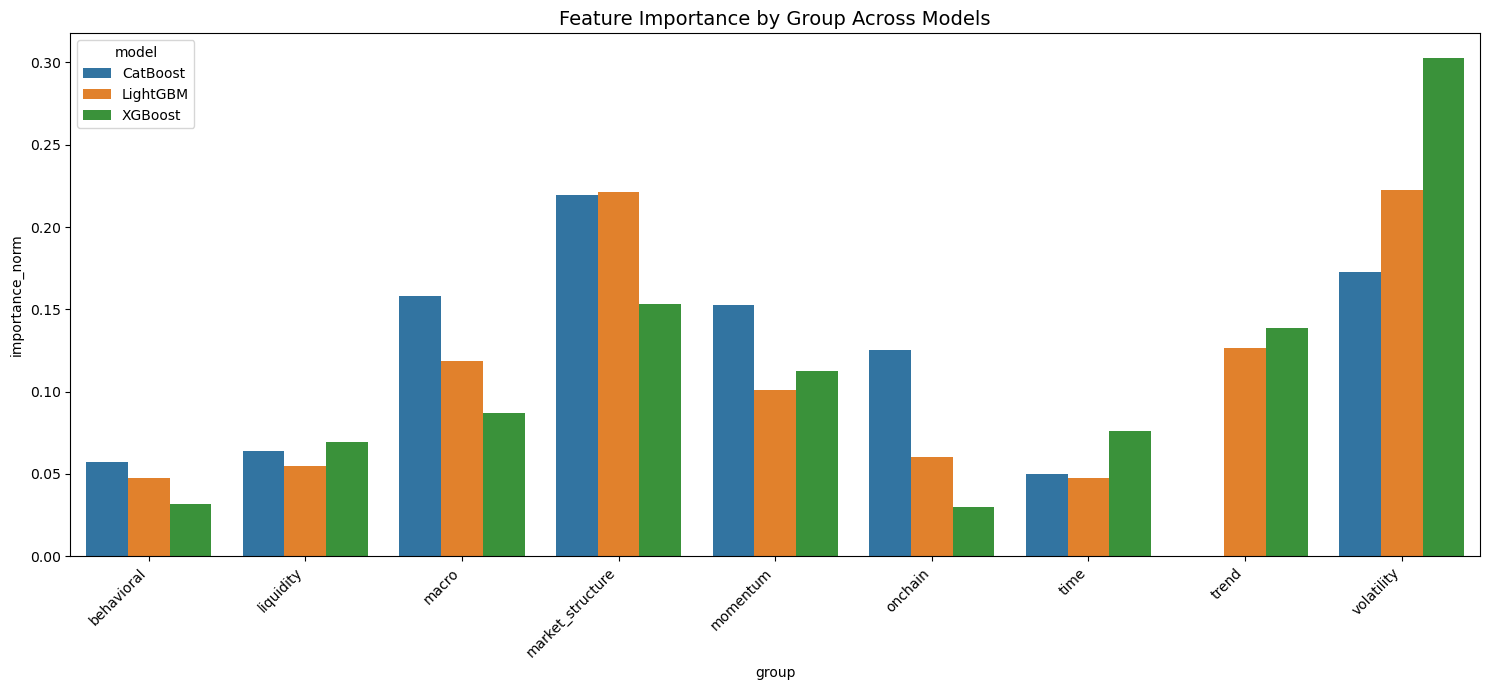

In [10]:
# ---------------------------------------------------------
# 6. ГРАФІК 1 — GROUPED BAR CHART
# ---------------------------------------------------------
plt.figure(figsize=(15, 7))
sns.barplot(data=df_importance, x='group', y='importance_norm', hue='model', palette="tab10",errorbar=None)
plt.title("Feature Importance by Group Across Models", fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

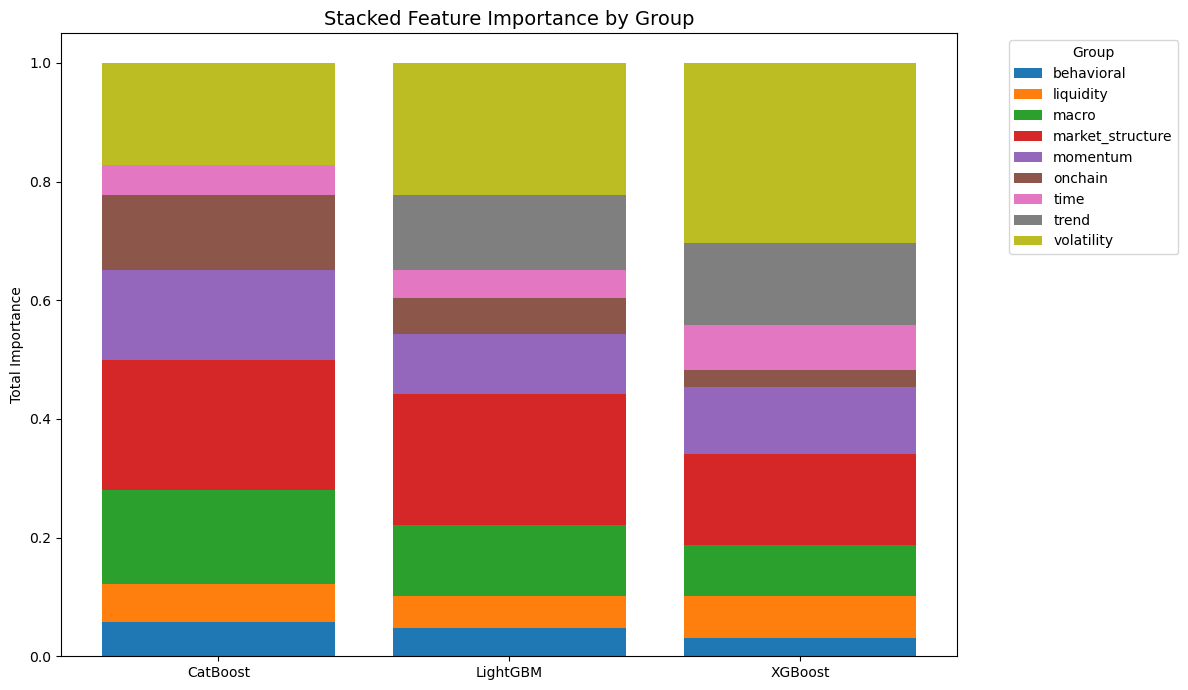

In [11]:

pivot = df_importance.pivot_table(
    index="model",
    columns="group",
    values="importance_norm",
    aggfunc="sum",
    fill_value=0
)

# ---------------------------------------------------------
# 7. ГРАФІК 2 — STACKED BAR CHART
# ---------------------------------------------------------
plt.figure(figsize=(12, 7))

bottom = np.zeros(len(pivot))
for col in pivot.columns:
    plt.bar(pivot.index, pivot[col], bottom=bottom, label=col)
    bottom += pivot[col]

plt.title("Stacked Feature Importance by Group", fontsize=14)
plt.ylabel("Total Importance")
plt.legend(title="Group", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

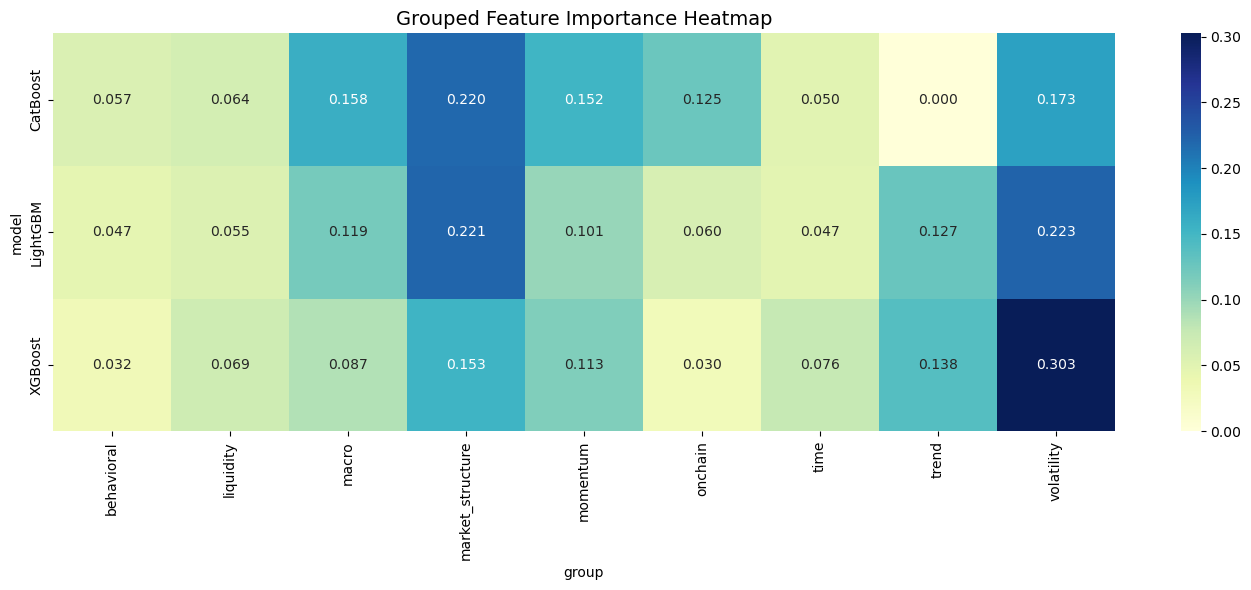

In [12]:
# ---------------------------------------------------------
# 8. ГРАФІК 3 — HEATMAP
# ---------------------------------------------------------
plt.figure(figsize=(14, 6))
sns.heatmap(pivot, annot=True, fmt=".3f", cmap="YlGnBu")
plt.title("Grouped Feature Importance Heatmap", fontsize=14)
plt.tight_layout()
plt.show()